## Importando as bibliotecas necessárias para o desenvolvimento

Importando as bibliotecas necessárias para o desenvolvimento

In [2]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# TO DO: Importar biblioteca de LogisticRegression do sklearn
from sklearn.linear_model import LogisticRegression


# Making the confusion Matrix
from sklearn.metrics import confusion_matrix

# Bibliotecas de vizualização de dados
import seaborn as sns
# import missingno as msno
import matplotlib.pyplot as plt

print(pd.__version__)
print(np.__version__)

2.2.2
1.26.4



## Realizando a carga dos dados


In [3]:
# TO DO: Realizar a carga dos dados do arquivo titanic.csv
titanic = pd.read_csv("/content/titanic.csv")

In [4]:
titanic.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0


In [6]:
#Análise Exploratória dos Dados
# TO DO: Apresentar informações estatísticas descritivas do dataste
titanic.describe()


,pclass,age,sibsp,parch,fare,survived
count,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,1309.000000
mean,2.294882,29.881135,0.498854,0.385027,33.295479,0.381971
std,0.837836,14.413500,1.041658,0.865560,51.758668,0.486055
min,1.000000,0.166700,0.000000,0.000000,0.000000,0.000000
25%,2.000000,21.000000,0.000000,0.000000,7.895800,0.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,3.000000,39.000000,1.000000,0.000000,31.275000,1.000000
max,3.000000,80.000000,8.000000,9.000000,512.329200,1.000000


## Início da Análise Exploratória de Dados


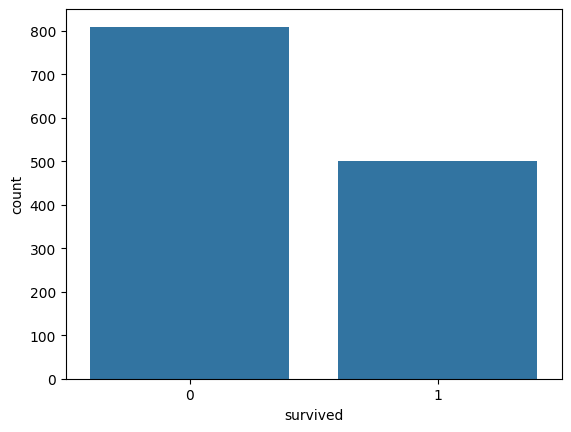

In [7]:
distribution = sns.countplot(x='survived', data = titanic)

In [9]:
# Apagando os atributos que não interessam a modelagem
# TO DO: Realizar a exclusão dos atributos (colunas) 'name', 'ticket' e 'cabin'
colunas_deletadas = ['name', 'ticket','cabin']
titanic = titanic.drop(colunas_deletadas, axis=1)


In [10]:
titanic.head()

,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,1,female,29.0000,0,0,211.3375,S,1
1,1,male,0.9167,1,2,151.5500,S,1
2,1,female,2.0000,1,2,151.5500,S,0
3,1,male,30.0000,1,2,151.5500,S,0
4,1,female,25.0000,1,2,151.5500,S,0


## Resolver valores ausentes - Missing Values

In [11]:
#Identifcando valores ausentes
print('-- Antes do tratamento --')
print(titanic.isnull().sum())

# print(titanic['pclass'].count())

# possibilidade 1 - Apagar os registros que contém valores ausentes
# TO DO: Realizar a exclusão dos registros com valores ausentes b
titanic = titanic.dropna()


-- Antes do tratamento --
pclass        0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
survived      0
dtype: int64


In [12]:
# TO DO: Realizar a exclusão dos registros com valores ausentes b
print('-- Depois do tratamento --')
titanic = titanic.dropna()
print(titanic.isnull().sum())

-- Depois do tratamento --
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


In [13]:
print('-- Informações sobre o dataset --')
titanic.info()

-- Informações sobre o dataset --
<class 'pandas.core.frame.DataFrame'>
Index: 1043 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1043 non-null   int64  
 1   sex       1043 non-null   object 
 2   age       1043 non-null   float64
 3   sibsp     1043 non-null   int64  
 4   parch     1043 non-null   int64  
 5   fare      1043 non-null   float64
 6   embarked  1043 non-null   object 
 7   survived  1043 non-null   int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 73.3+ KB


## Substituindo os valores categóricos (nominais) por valores numéricos

A função get_dummies do pacote pandas converte variáveis categóricas em variáveis dummy / indicadoras.




In [14]:
#Substituindo os valores categóricos (nominais) por valores numéricos - Dummy encoding
titanic = pd.get_dummies(titanic)

In [15]:
titanic.head()

,pclass,age,sibsp,parch,fare,survived,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,1,29.0000,0,0,211.3375,1,True,False,False,False,True
1,1,0.9167,1,2,151.5500,1,False,True,False,False,True
2,1,2.0000,1,2,151.5500,0,True,False,False,False,True
3,1,30.0000,1,2,151.5500,0,False,True,False,False,True
4,1,25.0000,1,2,151.5500,0,True,False,False,False,True


In [16]:
from IPython.display import display

#Usando o método loc com lógica booleana. Pegando todas as colunas diferentes de "survived"
X = titanic.loc[:,titanic.columns!="survived"].values
y = titanic.iloc[:, 5].values

display(X)
display(y)

array([[1, 29.0, 0, ..., False, False, True],
       [1, 0.9167, 1, ..., False, False, True],
       [1, 2.0, 1, ..., False, False, True],
       ...,
       [3, 26.5, 0, ..., True, False, False],
       [3, 27.0, 0, ..., True, False, False],
       [3, 29.0, 0, ..., False, False, True]], dtype=object)

array([1, 1, 0, ..., 0, 0, 0])

In [17]:
#Separação do dataset em treinamento e tests
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.30,
                                                    random_state=0)

## Feature Scaling

Uma das transformações mais importantes que você precisa aplicar aos seus dados é o dimensionamento de recursos (feature scaling). Com poucas exceções, os algoritmos de Aprendizado de Máquina não apresentam bom desempenho quando os atributos numéricos de entrada possuem escalas muito diferentes. Este é o caso da habitação. Dados: o número total de salas varia de cerca de 6 a 39.320, enquanto a renda média varia apenas de 0 a 15. Observe que o escalonamento dos valores-alvo geralmente não é necessário.

In [18]:
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

display(X_train)
display(X_test)

array([[ 0.95290282,  0.40753728, -0.5536323 , ..., -0.52981294,
        -0.23757092,  0.6121802 ],
       [ 0.95290282, -0.50457986, -0.5536323 , ..., -0.52981294,
        -0.23757092,  0.6121802 ],
       [-0.22611253, -0.15376557, -0.5536323 , ..., -0.52981294,
        -0.23757092,  0.6121802 ],
       ...,
       [ 0.95290282,  0.12688586, -0.5536323 , ..., -0.52981294,
        -0.23757092,  0.6121802 ],
       [ 0.95290282, -0.434417  , -0.5536323 , ..., -0.52981294,
        -0.23757092,  0.6121802 ],
       [ 0.95290282, -2.0949403 , -0.5536323 , ..., -0.52981294,
        -0.23757092,  0.6121802 ]])

array([[ 0.95290282, -1.48685986,  1.7892754 , ..., -0.52981294,
        -0.23757092,  0.6121802 ],
       [-0.22611253, -0.64490557, -0.5536323 , ..., -0.52981294,
        -0.23757092,  0.6121802 ],
       [ 0.95290282, -0.78523129,  0.61782155, ..., -0.52981294,
        -0.23757092,  0.6121802 ],
       ...,
       [-0.22611253, -1.27637129, -0.5536323 , ..., -0.52981294,
        -0.23757092,  0.6121802 ],
       [-0.22611253, -0.29409129, -0.5536323 , ..., -0.52981294,
        -0.23757092,  0.6121802 ],
       [-1.40512789, -0.78523129,  0.61782155, ..., -0.52981294,
        -0.23757092,  0.6121802 ]])

## Criando o classificador de Logistic Regression para o conjunto de treinamento


In [19]:
# TO DO: Instanciar um classificador para Regressão Logística (Logistic Regression)
#Parametros para o classificador random_state=0 e solver='lbfgs'
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()
# Trainando o modelo
classifier.fit(X_train, y_train)

LogisticRegression()

In [20]:
# Prevendo alguns valores com o conjunto de dados de teste

#Sem indicação de probabilidade
y_pred = classifier.predict(X_test)
y_pred

array([1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,

## Criando uma Matriz de Confusão para analisar o resultado da previsão feita pelo modelo

Podemos resumir nosso modelo de "predição de lobo" usando uma matriz de confusão 2x2 que descreve TO DOs os quatro resultados possíveis:

> Um verdadeiro positivo (TP) é um resultado em que o modelo prevê corretamente a classe positiva. Da mesma forma, um verdadeiro negativo é um resultado em que o modelo prevê corretamente a classe negativa.

> Um falso positivo (FP) é um resultado em que o modelo prevê incorretamente a classe positiva. E um falso negativo é um resultado em que o modelo prediz incorretamente a classe negativa.

In [21]:
# Making the confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[165,  21],
       [ 35,  92]])

## Verificando a acurácia do modelo utilizado

Precisão é uma métrica para avaliar modelos de classificação. Informalmente, a precisão é a fração de previsões que nosso modelo acertou.

In [22]:
# Acurácia do Logistic Regression

from sklearn.metrics import accuracy_score

for clf in (classifier,):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.8210862619808307
